## Imports & Setup

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score
)
from sklearn.preprocessing import StandardScaler
import shap

# Set visual styling
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

print("All libraries imported successfully!")

All libraries imported successfully!


## Load & Merge Kaggle Solar Datasets

In [2]:
# Define relative paths
data_dir = "../data/numerical"
gen_file = os.path.join(data_dir, "Plant_1_Generation_Data.csv")
weather_file = os.path.join(data_dir, "Plant_1_Weather_Sensor_Data.csv")

# Load raw datasets
df_gen = pd.read_csv(gen_file)
df_weather = pd.read_csv(weather_file)

# Standardize date-time format for merging
df_gen["DATE_TIME"] = pd.to_datetime(df_gen["DATE_TIME"], format="%d-%m-%Y %H:%M")
df_weather["DATE_TIME"] = pd.to_datetime(df_weather["DATE_TIME"])

# Merge power generation and weather readings on timestamp & plant ID
df_merged = pd.merge(df_gen, df_weather, on=["DATE_TIME", "PLANT_ID"])

# Filter out nighttime records (Irradiance near 0)
df_scada = df_merged[df_merged["IRRADIATION"] > 0.01].copy().reset_index(drop=True)

print(f"Loaded and merged {len(df_scada)} daytime SCADA records.")
print(df_scada[['DATE_TIME', 'DC_POWER', 'AC_POWER', 'MODULE_TEMPERATURE', 'IRRADIATION']].head())

Loaded and merged 35938 daytime SCADA records.
            DATE_TIME    DC_POWER   AC_POWER  MODULE_TEMPERATURE  IRRADIATION
0 2020-05-15 06:15:00  278.000000  26.862500           22.353459     0.022282
1 2020-05-15 06:15:00  310.571429  30.014286           22.353459     0.022282
2 2020-05-15 06:15:00  318.625000  30.775000           22.353459     0.022282
3 2020-05-15 06:15:00  316.250000  30.562500           22.353459     0.022282
4 2020-05-15 06:15:00  311.428571  30.100000           22.353459     0.022282


## Inject Panel Specifications & Compute Defect Labels

In [3]:
# --- ALPEX SOLAR ALP335W Datasheet Specifications ---
P_MAX_STC = 335.0       # Rated Max Power (W)[cite: 5]
V_MP_STC = 38.08        # Voltage at Max Power (V)[cite: 5]
I_MP_STC = 8.80         # Current at Max Power (A)[cite: 5]
TEMP_COEFF_P = -0.004   # Power temperature coefficient (-0.4%/°C)

# 1. Derive estimated physical voltage and current under dynamic weather conditions
temp_diff = df_scada["MODULE_TEMPERATURE"] - 25.0 # Delta T from STC (25°C)

df_scada["EST_I_MP"] = I_MP_STC * (df_scada["IRRADIATION"] / 1.0) # Current scales with sun intensity
df_scada["EST_V_MP"] = V_MP_STC * (1 - 0.003 * temp_diff)         # Voltage drops with heat

# 2. Estimate baseline expected DC power per array segment
# Average array scaling factor between inverter kW scale and panel W scale
avg_scale_factor = (df_scada["DC_POWER"] / df_scada["IRRADIATION"]).median()
df_scada["EXPECTED_DC_POWER"] = (
    avg_scale_factor * df_scada["IRRADIATION"] * (1 + TEMP_COEFF_P * temp_diff)
)

# 3. Calculate Performance Ratio (Actual vs Expected Output)
df_scada["PERFORMANCE_RATIO"] = df_scada["DC_POWER"] / (df_scada["EXPECTED_DC_POWER"] + 1e-5)

# 4. Generate Ground Truth Label: 1 = Fault/Degraded, 0 = Healthy
# Flag anomalies where performance ratio < 80% or zero output during daylight
df_scada["DEFECT_LABEL"] = np.where(
    (df_scada["PERFORMANCE_RATIO"] < 0.80) | (df_scada["DC_POWER"] == 0), 1, 0
)

print("Defect Class Distribution:")
print(df_scada["DEFECT_LABEL"].value_counts())
print(f"Defect Rate: {df_scada['DEFECT_LABEL'].mean() * 100:.2f}%")

Defect Class Distribution:
DEFECT_LABEL
0    35326
1      612
Name: count, dtype: int64
Defect Rate: 1.70%


## Feature Selection & Train/Test Split

In [4]:
# Select the 5 core SCADA features
feature_cols = [
    "DC_POWER",
    "AC_POWER",
    "AMBIENT_TEMPERATURE",
    "MODULE_TEMPERATURE",
    "IRRADIATION"
]

X = df_scada[feature_cols].copy()
y = df_scada["DEFECT_LABEL"].values

# Train-Test Split (Stratified to preserve defect ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Scale features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled test features back to DataFrame for clean SHAP plotting
X_test_df = pd.DataFrame(X_test_scaled, columns=feature_cols)

print(f"Training Samples: {X_train.shape[0]} | Testing Samples: {X_test.shape[0]}")

Training Samples: 28750 | Testing Samples: 7188


## Train XGBoost Model & Evaluate Performance

=== XGBoost SCADA Model Performance ===
Accuracy:  0.9829
ROC-AUC:   0.9899

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99      7066
           1       0.50      0.96      0.66       122

    accuracy                           0.98      7188
   macro avg       0.75      0.97      0.82      7188
weighted avg       0.99      0.98      0.99      7188



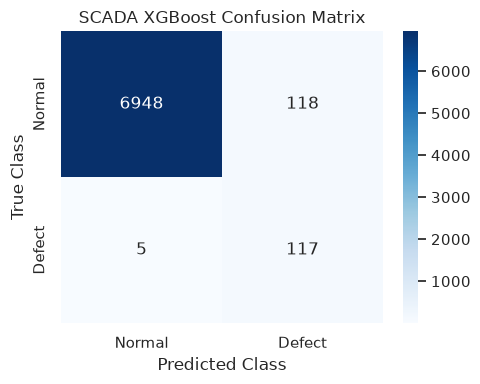

In [5]:
# Calculate class imbalance weighting factor
num_normal = (y_train == 0).sum()
num_defect = (y_train == 1).sum()
scale_weight = num_normal / max(1, num_defect)

# Initialize XGBoost Classifier
scada_model = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

# Train model
scada_model.fit(X_train_scaled, y_train)

# Predictions
y_preds = scada_model.predict(X_test_scaled)
y_probs = scada_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation Report
print("=== XGBoost SCADA Model Performance ===")
print(f"Accuracy:  {accuracy_score(y_test, y_preds):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_probs):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_preds))

# Plot Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_preds), annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Defect"], yticklabels=["Normal", "Defect"])
plt.title("SCADA XGBoost Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
plt.show()

### Training time is 1 sec
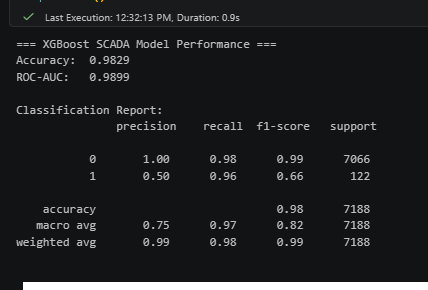

## Explainability via SHAP (SHapley Additive exPlanations)

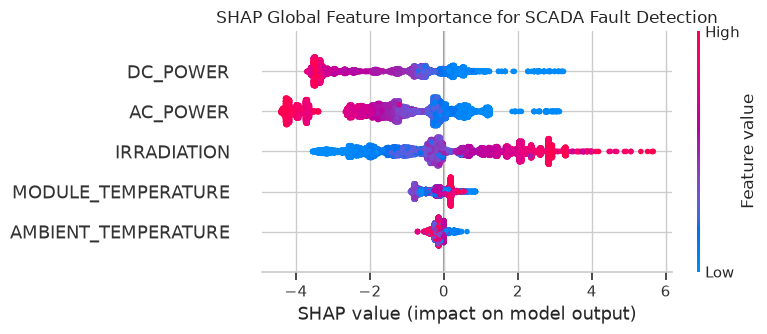

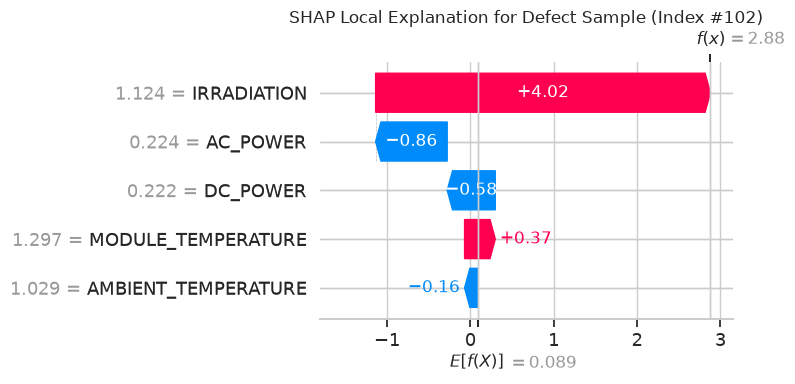

In [6]:
# Initialize SHAP TreeExplainer
explainer = shap.TreeExplainer(scada_model)
shap_values = explainer(X_test_df)

# 1. SHAP Feature Importance Summary Plot
plt.figure(figsize=(8, 5))
plt.title("SHAP Global Feature Importance for SCADA Fault Detection", fontsize=12)
shap.summary_plot(shap_values, X_test_df, show=False)
plt.tight_layout()
plt.show()

# 2. Individual Sample Explanation (Waterfall Plot)
sample_idx = np.where(y_test == 1)[0][0] # First detected defect sample
plt.figure(figsize=(8, 4))
plt.title(f"SHAP Local Explanation for Defect Sample (Index #{sample_idx})")
shap.plots.waterfall(shap_values[sample_idx], show=False)
plt.tight_layout()
plt.show()

## Export Model, Scaler & Cleaned Test Datasets

In [7]:
# Create target directories if they don't exist
os.makedirs("../models", exist_ok=True)
os.makedirs("../data/numerical", exist_ok=True)

# 1. Save Trained XGBoost Model & Scaler
joblib.dump(scada_model, "../models/xgboost_scada.joblib")
joblib.dump(scaler, "../models/scada_scaler.joblib")
print("Saved SCADA model to: ../models/xgboost_scada.joblib")

# 2. Save Cleaned Test Dataset with Matching Feature Columns
X_test_export = X_test.copy()
X_test_export["DEFECT_LABEL"] = y_test
X_test_export.to_csv("../data/numerical/scada_test.csv", index=False)
np.save("../data/numerical/test_scada_features.npy", X_test_scaled)

print("Saved test dataset to: ../data/numerical/scada_test.csv")
print("Saved scaled test array to: ../data/numerical/test_scada_features.npy")
print("SCADA Pipeline Setup & SHAP Explanation Complete!")

Saved SCADA model to: ../models/xgboost_scada.joblib
Saved test dataset to: ../data/numerical/scada_test.csv
Saved scaled test array to: ../data/numerical/test_scada_features.npy
SCADA Pipeline Setup & SHAP Explanation Complete!
